In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving archive (7).zip to archive (7).zip


{'archive (7).zip': b'PK\x03\x04-\x00\x00\x08\x08\x00\xd0@\rW\xc8\x11[z\xff\xff\xff\xff\xff\xff\xff\xff\x11\x00\x14\x00employee_data.csv\x01\x00\x10\x00\xde\xe6\x0b\x00\x00\x00\x00\x00\x8f\x08\x03\x00\x00\x00\x00\x00\xb4\xbd\xd9\x92\xe3H\xb2%\xf8>"\xf3\x0fxj\xe9\x11A\xa2\xb1\x03|k_b\xcb\x08\x8f\xf4v\x8f\xca\xe8\xac7#\t\'\x11\x0e\x02,\x80t\x0f\xc6\xaf\xcd\xc3|\xd2\xfc\xc2\xe8Q3\x03\x17\xc0\x00x\xe6\x9d{K\xaa"<\xdc\x8c\xb4M\xf5\xe8v\xf4\xff\xfd\xbf\xff\x9fw\x9b\xed\xa7[\xfb}^7\xbb\xafb\x93\xd9_\x84\xfa\xc3\xe3N\xd4\xbb[\xb1\xcb\xecw?s\xf9\x87o\xf9\xae\xa0\x7f\xd8o\xb3\xfa%o\xaa\xda\xbe\xba}\xb7\x11ya_\xef\x9b\xbc\xcc\x9a\xe6_e\xbe\xb3i\xc6\xa2:d\x19M\xb0\xdb7\xed_\xbf\x1d\xb6\x99}/\x0e\xff\xae\xca\xac\xfd\xe1M!\x9a&\x7f\xca\x17b\x97W%\xff\xca\xb7\xac\xde\xe4e\xef\xdfo\xb3fQ\xe7[\xfc\xd1\xbe\xcd\xb6\xf4\xfd6Y\xb9\xe3\xdf\xba\xcd\xe9\x1b\xf1\xcf\xff\xb8\xc6W\xa7o\xfb{5\x7f\xbf/\x17\x97\x03?d\xe52\xabo\xaa%\xad\xb5\x92\x9f\xcb\x7fy\x10\x8b\x0c\xbfg\xdf\x89:\xdf\x89\x82\xff|\x9f\xd5OU\xbd\x1

In [3]:
!unzip archive\ \(7\).zip

Archive:  archive (7).zip
  inflating: employee_data.csv       
  inflating: employee_engagement_survey_data.csv  
  inflating: recruitment_data.csv    
  inflating: training_and_development_data.csv  


In [7]:
import pandas as pd
df = pd.read_csv('employee_data.csv')
df.head()

,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Division,DOB,State,JobFunctionDescription,GenderCode,LocationCode,RaceDesc,MaritalDesc,Performance Score,Current Employee Rating
0,3427,Uriah,Bridges,20-Sep-19,NaN,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,Finance & Accounting,07-10-1969,MA,Accounting,Female,34904,White,Widowed,Fully Meets,4
1,3428,Paula,Small,11-Feb-23,NaN,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,Aerial,30-08-1965,MA,Labor,Male,6593,Hispanic,Widowed,Fully Meets,3
2,3429,Edward,Buck,10-Dec-18,NaN,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,General - Sga,06-10-1991,MA,Assistant,Male,2330,Hispanic,Widowed,Fully Meets,4
3,3430,Michael,Riordan,21-Jun-21,NaN,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,Finance & Accounting,04-04-1998,ND,Clerk,Male,58782,Other,Single,Fully Meets,2
4,3431,Jasmine,Onque,29-Jun-19,NaN,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,General - Con,29-08-1969,FL,Laborer,Female,33174,Other,Married,Fully Meets,3


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   EmpID                       3000 non-null   int64 
 1   FirstName                   3000 non-null   object
 2   LastName                    3000 non-null   object
 3   StartDate                   3000 non-null   object
 4   ExitDate                    1533 non-null   object
 5   Title                       3000 non-null   object
 6   Supervisor                  3000 non-null   object
 7   ADEmail                     3000 non-null   object
 8   BusinessUnit                3000 non-null   object
 9   EmployeeStatus              3000 non-null   object
 10  EmployeeType                3000 non-null   object
 11  PayZone                     3000 non-null   object
 12  EmployeeClassificationType  3000 non-null   object
 13  TerminationType             3000 non-null   obje

In [10]:
df = df.select_dtypes(include=['int64','float64'])

In [11]:
df =df.dropna()

In [13]:
print(df.shape)

(3000, 3)


In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3,random_state=0)
df['cluster']= kmeans.fit_predict(df)

df.head()

,EmpID,LocationCode,Current Employee Rating,cluster
0,3427,34904,4,0
1,3428,6593,3,1
2,3429,2330,4,1
3,3430,58782,2,0
4,3431,33174,3,0


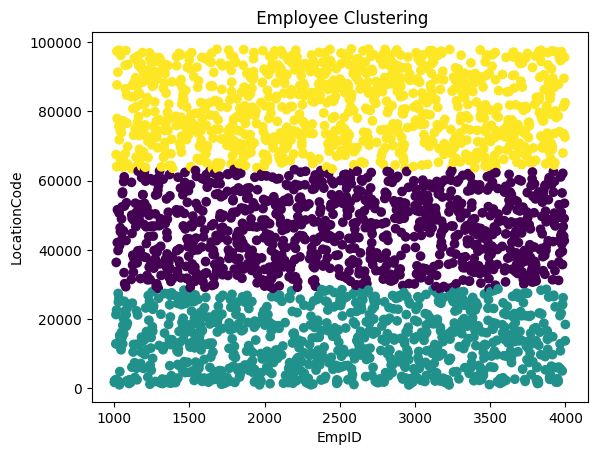

In [15]:
import matplotlib.pyplot as plt

plt.scatter(df.iloc[:,0],df.iloc[:,1],c=df['cluster'])
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title(' Employee Clustering')
plt.show()
